# ETF Portfolio Analytics

## Notebook 01 — Historical Data Loading

This notebook validates the data loading module and retrieves historical adjusted closing prices for selected ETFs.

### Objectives

- test the `load_price_data()` function;
- inspect downloaded market data;
- verify the structure of the dataset;
- prepare the data for return calculations.

In [10]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [11]:
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

PROJECT_ROOT

WindowsPath('f:/Investment Projects/etf-portfolio-analytics')

In [13]:
from src.data_loader import load_price_data
from src.risk_metrics import (
    calculate_annualized_volatility,
    calculate_cumulative_returns,
    calculate_daily_returns,
)

In [16]:
prices = load_price_data(
    tickers=["SPY", "VOO", "QQQ"],
    start_date="2026-01-01",
    end_date="2026-07-20",
)

prices.head(10)

,QQQ,SPY,VOO
Date,,,
2026-01-02,611.675659,679.558594,624.504333
2026-01-05,616.534180,684.084595,628.639221
2026-01-06,621.951416,688.152954,632.366577
2026-01-07,622.550049,685.934753,630.338806
2026-01-08,619.008362,685.865112,630.229553
2026-01-09,625.173828,690.401001,634.453918
2026-01-12,625.692566,691.485229,635.477722
2026-01-13,624.764771,690.102600,634.175598
2026-01-14,618.090515,686.710571,631.104248


In [17]:
prices.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 135 entries, 2026-01-02 to 2026-07-17
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   QQQ     135 non-null    float64
 1   SPY     135 non-null    float64
 2   VOO     135 non-null    float64
dtypes: float64(3)
memory usage: 4.2 KB


In [18]:
prices.describe()

,QQQ,SPY,VOO
count,135.000000,135.000000,135.000000
mean,653.126202,704.518813,647.453828
std,54.739834,33.868002,31.157065
min,557.667175,630.346069,579.243164
25%,606.532837,680.210144,625.115631
50%,627.947205,691.743835,635.815552
75%,711.589996,737.360352,677.626678
max,745.340881,757.618225,696.232544


In [19]:
prices.dtypes

QQQ    float64
SPY    float64
VOO    float64
dtype: object

In [20]:
prices.index

DatetimeIndex(['2026-01-02', '2026-01-05', '2026-01-06', '2026-01-07',
               '2026-01-08', '2026-01-09', '2026-01-12', '2026-01-13',
               '2026-01-14', '2026-01-15',
               ...
               '2026-07-06', '2026-07-07', '2026-07-08', '2026-07-09',
               '2026-07-10', '2026-07-13', '2026-07-14', '2026-07-15',
               '2026-07-16', '2026-07-17'],
              dtype='datetime64[s]', name='Date', length=135, freq=None)

In [21]:
prices.shape

(135, 3)

<Axes: xlabel='Date'>

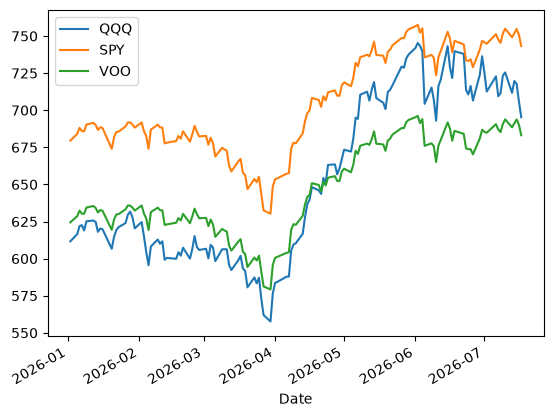

In [22]:
prices.plot()

In [23]:
#Finding correlation between the ETFs using the corr() method.
prices.corr()

,QQQ,SPY,VOO
QQQ,1.000000,0.982657,0.982588
SPY,0.982657,1.000000,0.999990
VOO,0.982588,0.999990,1.000000


# 2. Daily and Cumulative Returns

In this section we calculate:

- daily returns;
- cumulative returns.

These metrics form the foundation of nearly all quantitative portfolio analysis.

In [40]:
daily_returns = calculate_daily_returns(prices)

daily_returns.head(10)

,QQQ,SPY,VOO
Date,,,
2026-01-05,0.007943,0.006660,0.006621
2026-01-06,0.008787,0.005947,0.005929
2026-01-07,0.000963,-0.003223,-0.003207
2026-01-08,-0.005689,-0.000102,-0.000173
2026-01-09,0.009960,0.006613,0.006703
2026-01-12,0.000830,0.001570,0.001614
2026-01-13,-0.001483,-0.002000,-0.002049
2026-01-14,-0.010683,-0.004915,-0.004843
2026-01-15,0.003599,0.002723,0.002646


In [41]:
daily_returns.shape

(134, 3)

In [42]:
prices.shape, daily_returns.shape

((135, 3), (134, 3))

In [43]:
cumulative_returns = calculate_cumulative_returns(daily_returns)

cumulative_returns.head()

,QQQ,SPY,VOO
Date,,,
2026-01-05,1.007943,1.006660,1.006621
2026-01-06,1.016799,1.012647,1.012590
2026-01-07,1.017778,1.009383,1.009343
2026-01-08,1.011988,1.009280,1.009168
2026-01-09,1.022068,1.015955,1.015932


In [44]:
cumulative_returns.tail(1)

,QQQ,SPY,VOO
Date,,,
2026-07-17,1.136763,1.093784,1.09394


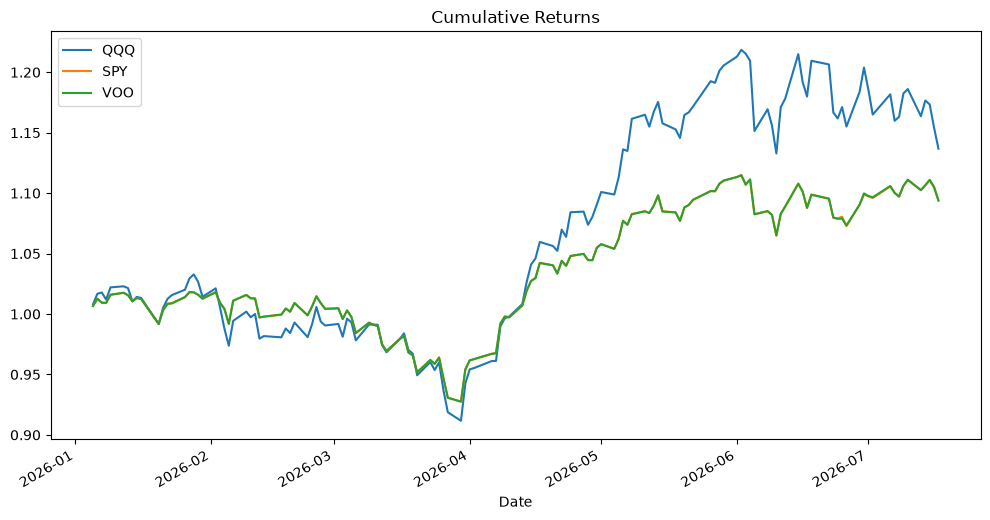

In [45]:
cumulative_returns.plot(
    figsize=(12,6),
    title="Cumulative Returns"
);

In [46]:
import pandas as pd

example_returns = pd.Series([0.10, 0.05, -0.02])

comparison = pd.DataFrame({
    "Daily Return": example_returns,
    "Cumulative Sum": example_returns.cumsum(),
    "Growth Factor": 1 + example_returns,
    "Cumulative Product": (1 + example_returns).cumprod()
})

comparison

,Daily Return,Cumulative Sum,Growth Factor,Cumulative Product
0,0.10,0.10,1.10,1.1000
1,0.05,0.15,1.05,1.1550
2,-0.02,0.13,0.98,1.1319


In [50]:
total_return_percent = (
    cumulative_returns.iloc[-1]   #.iloc[-1] takes the last line
    .sub(1)                       # turns growth factor into return
    .mul(100)                     # turns decimals format into percent     
    .round(2)                     # rounds to 2 decimal places
    .sort_values(ascending=False) #sorts values in descending order
)
total_return_percent.name = "Total Return (%)"
total_return_percent

QQQ    13.68
VOO     9.39
SPY     9.38
Name: Total Return (%), dtype: float64

In [52]:
#Annual Volatility
annualized_volatility = calculate_annualized_volatility(daily_returns)

annualized_volatility 

QQQ    0.214755
SPY    0.139045
VOO    0.138504
dtype: float64

In [53]:
annualized_volatility_percent = (
    annualized_volatility
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)
annualized_volatility_percent.name = "Annualized Volatility (%)"
annualized_volatility_percent

QQQ    21.48
SPY    13.90
VOO    13.85
Name: Annualized Volatility (%), dtype: float64

### Results Interpretation

As expected:

QQQ should exhibit higher volatility.
SPY and VOO should have nearly identical volatility.

### Why are SPY and VOO so similar?
Because both ETFs are designed to track the S&P 500 Index, resulting in highly comparable return and risk characteristics.

### Why does QQQ differ?
Because it tracks the Nasdaq-100 Index, which has a significantly higher concentration in large-cap technology and growth-oriented companies. This sector concentration generally leads to greater price fluctuations and higher volatility compared with broad-market S&P 500 ETFs.

In [ ]:
# Verify that the function calculates annualized volatility correctly by
# manually computing it as the standard deviation of daily returns multiplied
# by the square root of 252 (the approximate number of trading days in a year).

manual_volatility = daily_returns.std() * (252 ** 0.5)

comparison = pd.DataFrame({
    "Function Result": annualized_volatility,
    "Manual Result": manual_volatility,
    "Difference": annualized_volatility - manual_volatility,
})

comparison

,Function Result,Manual Result,Difference
QQQ,0.214755,0.214755,0.0
SPY,0.139045,0.139045,0.0
VOO,0.138504,0.138504,0.0
